<a href="https://colab.research.google.com/github/14marcos1/ELT578/blob/main/teste2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Área da ferida em pixels: 125685.5
-- Máscara de Segmentação --


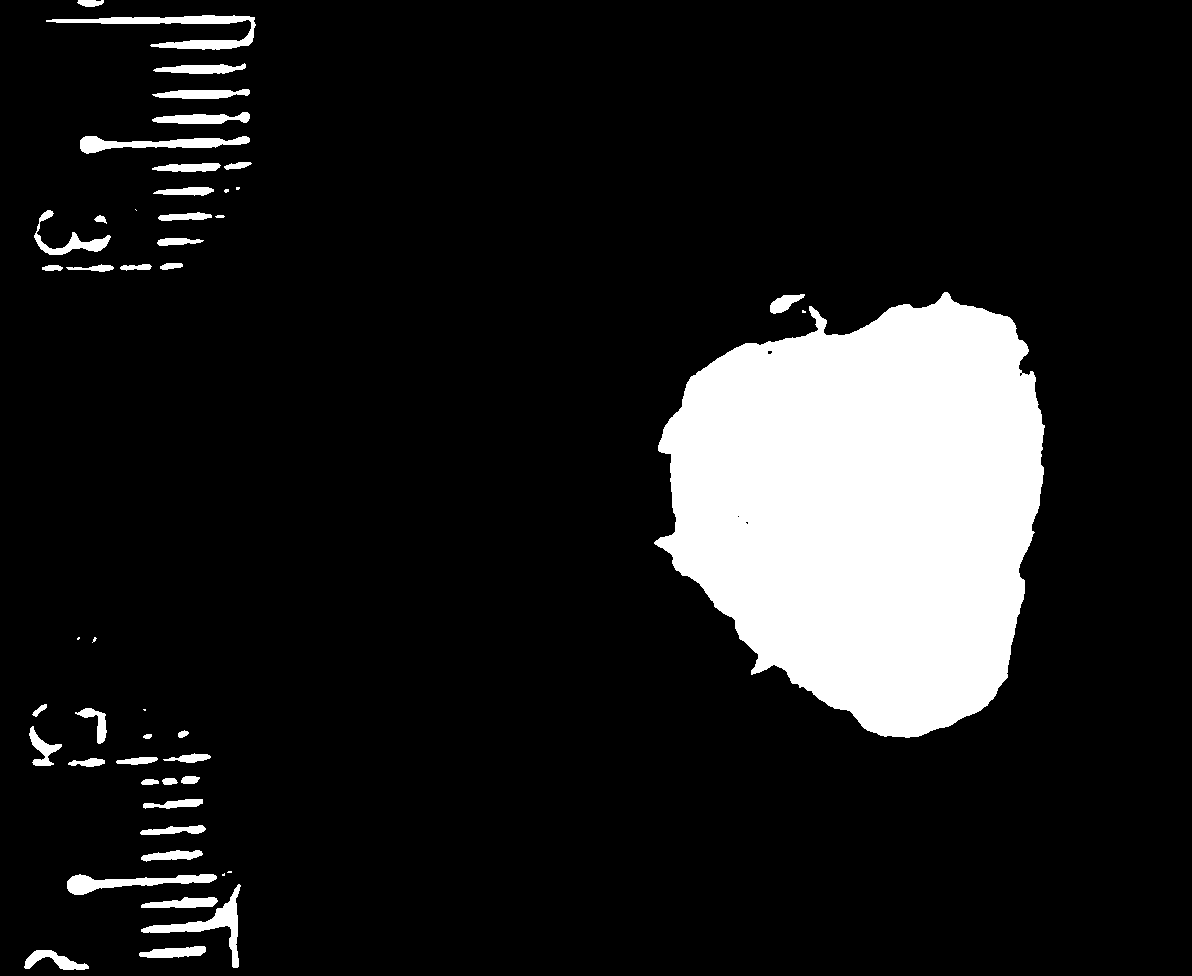

-- Contorno Detectado --


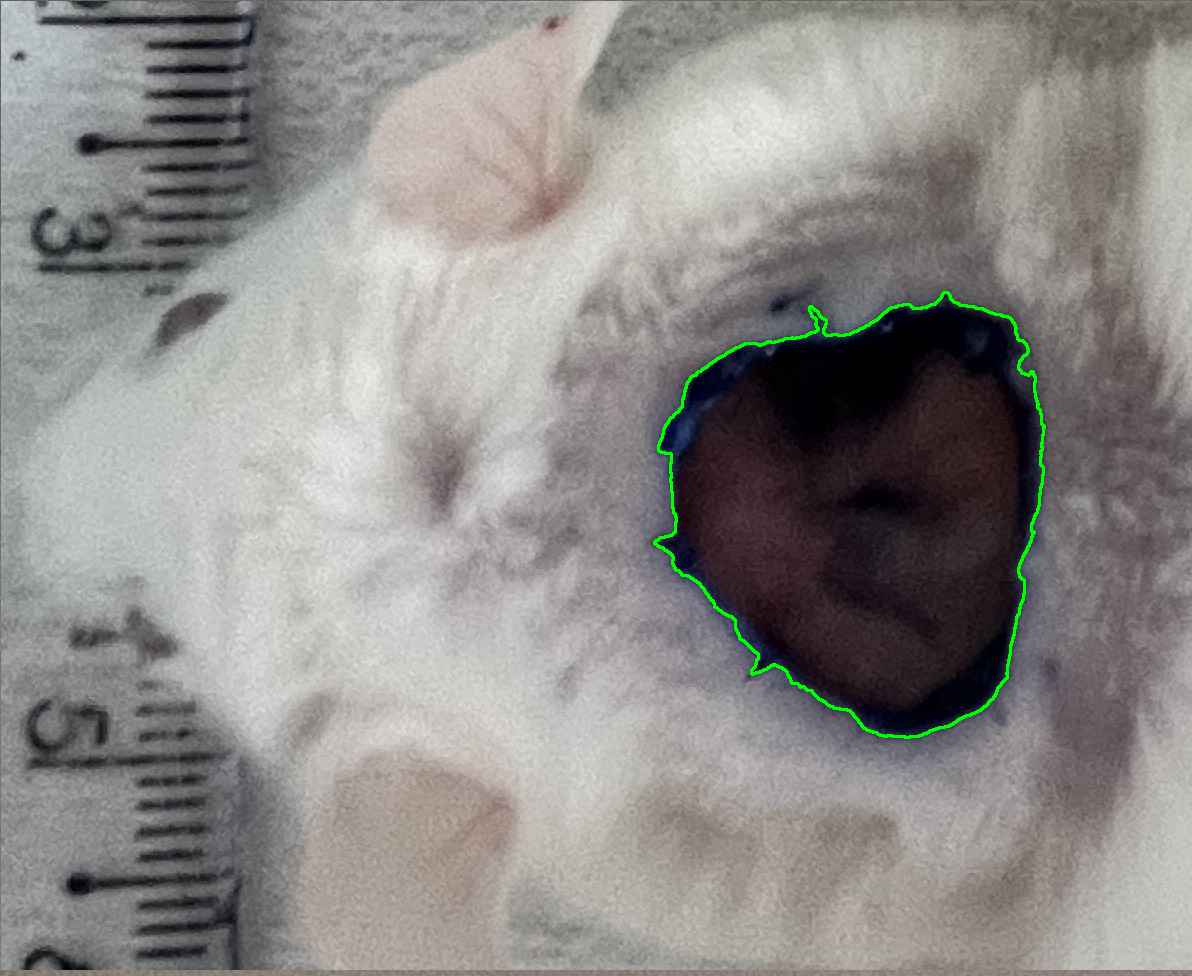

In [5]:
import cv2
import numpy as np
# Importação específica para o Colab
from google.colab.patches import cv2_imshow

# 1. Carregar a imagem (certifique-se que o arquivo TESTE_1.jpg está na pasta lateral)
image = cv2.imread('TESTE_1.jpg')
img_display = image.copy()

# 2. Processamento
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 0)

# 3. Thresholding (Ajuste o 60 se a máscara não pegar a ferida toda)
_, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY_INV)

# 4. Encontrar Contornos
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if contours:
    c = max(contours, key=cv2.contourArea)
    area_pixels = cv2.contourArea(c)

    # Desenhar o contorno
    cv2.drawContours(img_display, [c], -1, (0, 255, 0), 2)

    print(f"Área da ferida em pixels: {area_pixels}")

# 5. Mostrar resultados no Colab
print("-- Máscara de Segmentação --")
cv2_imshow(thresh)

print("-- Contorno Detectado --")
cv2_imshow(img_display)

In [6]:
# --- CALCULO DE ESCALA ---
# 1. Meça manualmente a distância em pixels entre 1cm (10mm) na régua da sua imagem
# Vamos supor que 10mm equivalem a 250 pixels (AJUSTE ESTE VALOR)
pixels_por_10mm = 250

# 2. Calcular a proporção (1 pixel linear = X mm)
pixel_linear_em_mm = 10 / pixels_por_10mm

# 3. Calcular a área real (Área em mm² = área_pixels * proporção²)
area_mm2 = area_pixels * (pixel_linear_em_mm ** 2)

print(f"Área calculada: {area_mm2:.2f} mm²")

Área calculada: 201.10 mm²
